In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mlxtend.plotting import plot_decision_regions
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier,plot_tree

In [17]:
df = pd.DataFrame({
    'X1': [1,2,3,4,5,6,6,7,9,9],
    'X2': [5,3,6,8,1,9,5,8,9,2],
    'label': [1,1,0,1,0,1,0,1,0,0]
})
df['Weight'] = 1 / df.shape[0]
X = df.iloc[:,0:2]
y = df.iloc[:,-2]

In [18]:
model = DecisionTreeClassifier(max_depth=1)
model.fit(X, y)

print(model)

DecisionTreeClassifier(max_depth=1)


[Text(0.5, 0.75, 'x[1] <= 2.5\ngini = 0.5\nsamples = 10\nvalue = [5, 5]'), Text(0.25, 0.25, 'gini = 0.0\nsamples = 2\nvalue = [2, 0]'), Text(0.375, 0.5, 'True  '), Text(0.75, 0.25, 'gini = 0.469\nsamples = 8\nvalue = [3, 5]'), Text(0.625, 0.5, '  False')]


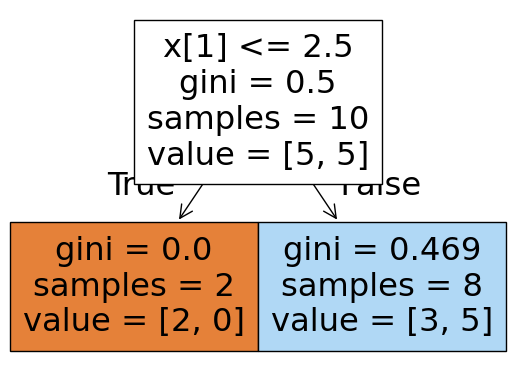

In [19]:
print(plot_tree(model,filled=True))

C:\Users\Admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


<Axes: >

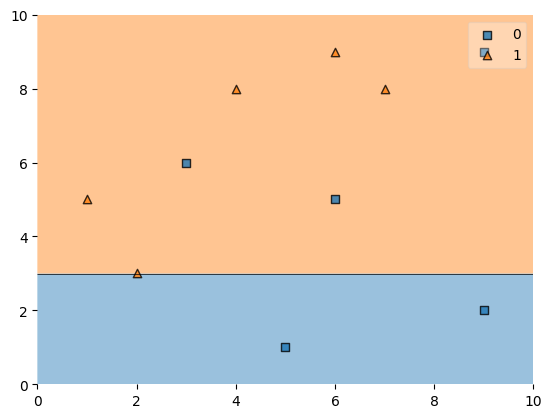

In [20]:
plot_decision_regions(X.values, y.values, clf=model)

In [21]:
df["Perdict"]=model.predict(X)
df

,X1,X2,label,Weight,Perdict
0,1,5,1,0.1,1
1,2,3,1,0.1,1
2,3,6,0,0.1,1
3,4,8,1,0.1,1
4,5,1,0,0.1,0
5,6,9,1,0.1,1
6,6,5,0,0.1,1
7,7,8,1,0.1,1
8,9,9,0,0.1,1
9,9,2,0,0.1,0


In [24]:
def error(error):
    return 0.5*np.log((1-error)/error)

In [25]:
alpha1=error(0.3)
alpha1

np.float64(0.42364893019360184)

In [27]:
def update_weight(row, alpha=0.423):
    if row['label'] == row['Perdict']:
        return row['Weight'] * np.exp(-alpha)
    else:
        return row['Weight'] * np.exp(alpha)


In [28]:
df['update_weight'] = df.apply(update_weight, axis=1)
df

,X1,X2,label,Weight,Perdict,update_weight
0,1,5,1,0.1,1,0.065508
1,2,3,1,0.1,1,0.065508
2,3,6,0,0.1,1,0.152653
3,4,8,1,0.1,1,0.065508
4,5,1,0,0.1,0,0.065508
5,6,9,1,0.1,1,0.065508
6,6,5,0,0.1,1,0.152653
7,7,8,1,0.1,1,0.065508
8,9,9,0,0.1,1,0.152653
9,9,2,0,0.1,0,0.065508


In [30]:
df['Normalize_Weight'] = df['update_weight'] / df['update_weight'].sum()
df

,X1,X2,label,Weight,Perdict,update_weight,Normalize_Weight
0,1,5,1,0.1,1,0.065508,0.071475
1,2,3,1,0.1,1,0.065508,0.071475
2,3,6,0,0.1,1,0.152653,0.166559
3,4,8,1,0.1,1,0.065508,0.071475
4,5,1,0,0.1,0,0.065508,0.071475
5,6,9,1,0.1,1,0.065508,0.071475
6,6,5,0,0.1,1,0.152653,0.166559
7,7,8,1,0.1,1,0.065508,0.071475
8,9,9,0,0.1,1,0.152653,0.166559
9,9,2,0,0.1,0,0.065508,0.071475


In [34]:
df['upper'] = np.cumsum(df['Normalize_Weight'])
df['lower'] = df['upper'] - df['Normalize_Weight']

df[['X1','X2','label','Weight','Perdict',
    'update_weight','Normalize_Weight','lower','upper']]


,X1,X2,label,Weight,Perdict,update_weight,Normalize_Weight,lower,upper
0,1,5,1,0.1,1,0.065508,0.071475,0.000000,0.071475
1,2,3,1,0.1,1,0.065508,0.071475,0.071475,0.142950
2,3,6,0,0.1,1,0.152653,0.166559,0.142950,0.309508
3,4,8,1,0.1,1,0.065508,0.071475,0.309508,0.380983
4,5,1,0,0.1,0,0.065508,0.071475,0.380983,0.452458
5,6,9,1,0.1,1,0.065508,0.071475,0.452458,0.523933
6,6,5,0,0.1,1,0.152653,0.166559,0.523933,0.690492
7,7,8,1,0.1,1,0.065508,0.071475,0.690492,0.761967
8,9,9,0,0.1,1,0.152653,0.166559,0.761967,0.928525
9,9,2,0,0.1,0,0.065508,0.071475,0.928525,1.000000


In [45]:
df = pd.DataFrame({
    'X1': [1,2,3,4,5,6,6,7,9,9],
    'X2': [5,3,6,8,1,9,5,8,9,2],
    'label': [1,1,0,1,0,1,0,1,0,0]
})

# Initialize weights
df['Weight'] = 1 / len(df)
df['label'] = df['label'].replace({0: -1, 1: 1})
df

,X1,X2,label,Weight
0,1,5,1,0.1
1,2,3,1,0.1
2,3,6,-1,0.1
3,4,8,1,0.1
4,5,1,-1,0.1
5,6,9,1,0.1
6,6,5,-1,0.1
7,7,8,1,0.1
8,9,9,-1,0.1
9,9,2,-1,0.1


In [46]:
# Step 2: Decision Stump (From Scratch)
def decision_stump(df, feature):
    values = sorted(df[feature].unique())
    thresholds = [(values[i] + values[i+1]) / 2 for i in range(len(values)-1)]

    best_error = np.inf
    best_stump = None

    for threshold in thresholds:
        for polarity in [1, -1]:
            preds = np.ones(len(df))
            preds[df[feature] < threshold] = -1
            preds *= polarity

            error = np.sum(df['Weight'][preds != df['label']])

            if error < best_error:
                best_error = error
                best_stump = {
                    'feature': feature,
                    'threshold': threshold,
                    'polarity': polarity
                }

    return best_stump, best_error


In [47]:
# Step 3: Alpha (Classifier Weight)
def compute_alpha(error):
    return 0.5 * np.log((1 - error) / error)


In [48]:
# Step 4: Predict Using Stump
def stump_predict(df, stump):
    preds = np.ones(len(df))
    preds[df[stump['feature']] < stump['threshold']] = -1
    return preds * stump['polarity']


In [49]:
# Step 5: Update Weights
def update_weights(df, alpha, preds):
    df['Weight'] = df['Weight'] * np.exp(-alpha * df['label'] * preds)
    df['Weight'] = df['Weight'] / df['Weight'].sum()
    return df


In [50]:
# Step 6: AdaBoost Training Loop
def train_adaboost(df, T=5):
    classifiers = []

    for t in range(T):
        best_stump, error = None, np.inf

        for feature in ['X1', 'X2']:
            stump, err = decision_stump(df, feature)
            if err < error:
                best_stump, error = stump, err

        alpha = compute_alpha(error)
        preds = stump_predict(df, best_stump)

        df = update_weights(df, alpha, preds)

        classifiers.append((best_stump, alpha))

        print(f"Iteration {t+1}")
        print("Stump:", best_stump)
        print("Error:", round(error, 4))
        print("Alpha:", round(alpha, 4))
        print("-"*40)

    return classifiers


In [51]:
# Step 7: Train Model
classifiers = train_adaboost(df, T=5)


Iteration 1
Stump: {'feature': 'X1', 'threshold': np.float64(2.5), 'polarity': -1}
Error: 0.3
Alpha: 0.4236
----------------------------------------
Iteration 2
Stump: {'feature': 'X1', 'threshold': np.float64(8.0), 'polarity': -1}
Error: 0.2143
Alpha: 0.6496
----------------------------------------
Iteration 3
Stump: {'feature': 'X2', 'threshold': np.float64(7.0), 'polarity': 1}
Error: 0.1364
Alpha: 0.9229
----------------------------------------
Iteration 4
Stump: {'feature': 'X1', 'threshold': np.float64(2.5), 'polarity': -1}
Error: 0.1842
Alpha: 0.744
----------------------------------------
Iteration 5
Stump: {'feature': 'X1', 'threshold': np.float64(8.0), 'polarity': -1}
Error: 0.1774
Alpha: 0.767
----------------------------------------


In [52]:
# Step 8: Final Strong Classifier
def adaboost_predict(df, classifiers):
    final_pred = np.zeros(len(df))

    for stump, alpha in classifiers:
        final_pred += alpha * stump_predict(df, stump)

    return np.sign(final_pred)


In [53]:
# Step 9: Accuracy
final_predictions = adaboost_predict(df, classifiers)

accuracy = np.mean(final_predictions == df['label'])
print("Final Accuracy:", accuracy)


Final Accuracy: 1.0
